In [1]:
import kagglehub

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import os
import glob
from pathlib import Path
import cv2
from PIL import Image
import yaml


import warnings
warnings.filterwarnings("ignore")

In [5]:
path = Path("/kaggle/input/competitions/aptos2019-blindness-detection")
print(os.listdir(path))
train_df = pd.read_csv(path / "train.csv")
train_df.head()


['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [7]:
test_df = pd.read_csv(path / "test.csv")
test_df.head()

,id_code
0,0005cfc8afb6
1,003f0afdcd15
2,006efc72b638
3,00836aaacf06
4,009245722fa4


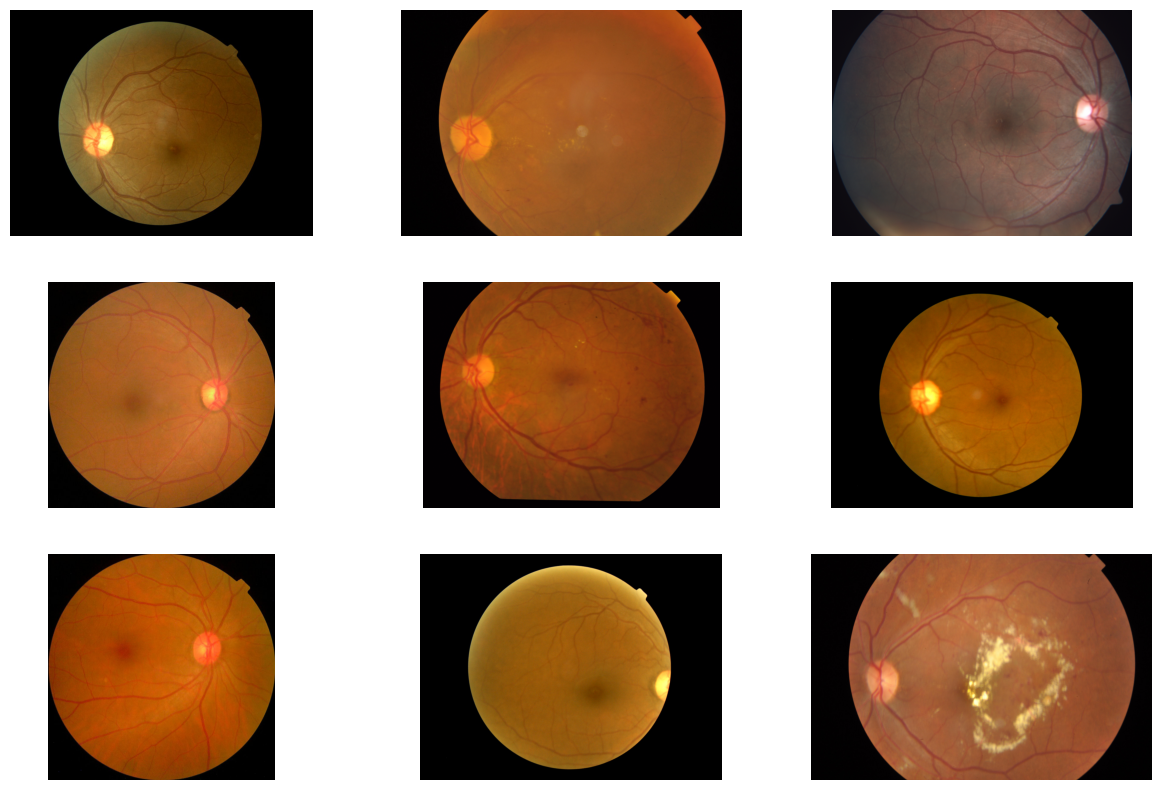

In [12]:
#visualize images from train_folder
train_folder_path = path / "train_images"
train_images = glob.glob(str(train_folder_path / "*.png"))
len(train_images)
train_images

#plotting some of the images
plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = Image.open(train_images[i])
    plt.imshow(img)
    plt.axis("off")
plt.show()

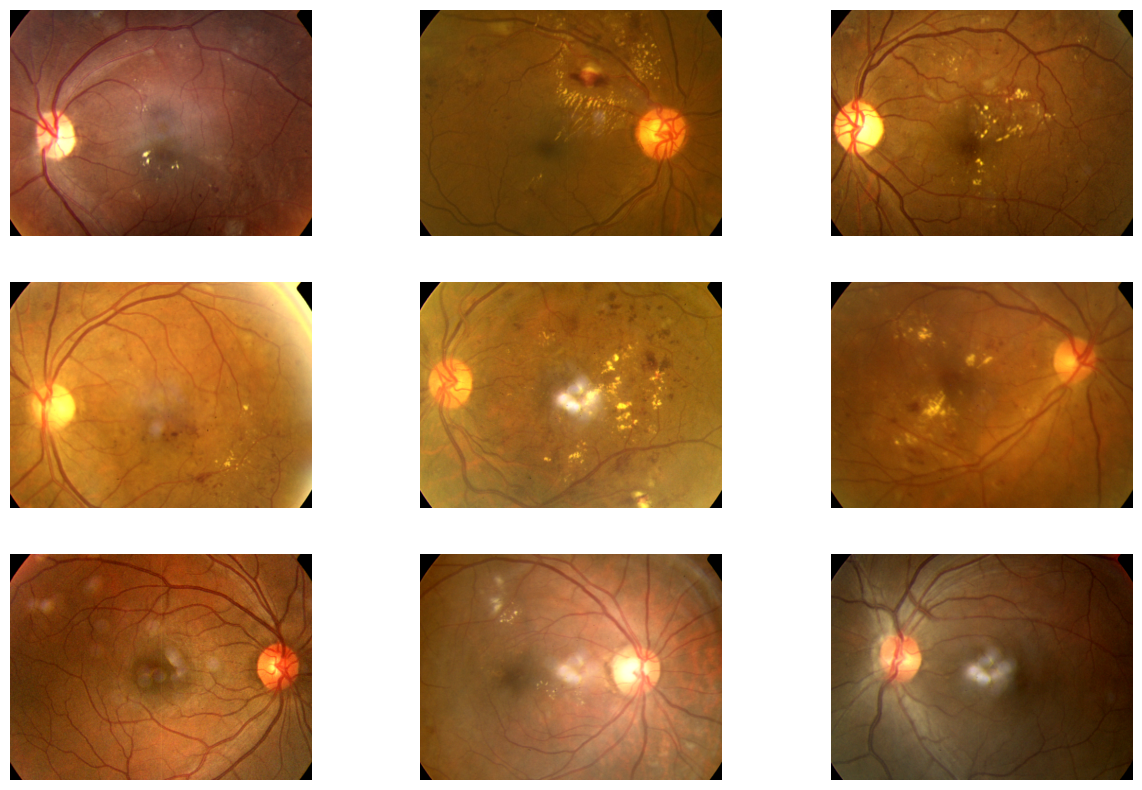

In [13]:
# visualize images from test_images folder
test_images_path = path / "test_images"
test_images = list(test_images_path.glob("*.png"))
len(test_images)
test_images[:5]

#plotting images from test_images folder
plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = Image.open(test_images[i])
    plt.imshow(img)
    plt.axis("off")
plt.show()